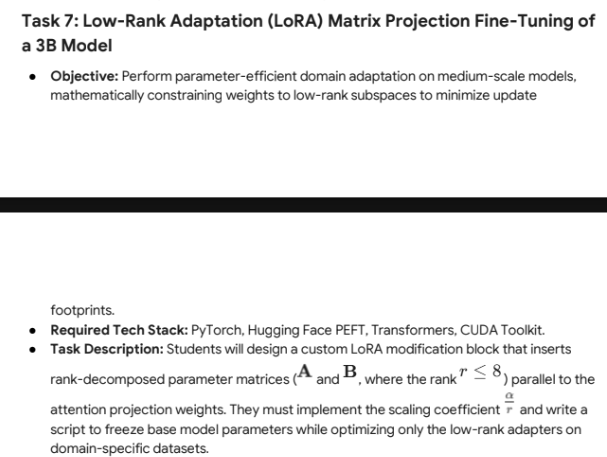

In [7]:
!pip install -q torch transformers peft datasets accelerate matplotlib torchao --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [8]:
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer
)

from peft import (
    LoraConfig,
    get_peft_model
)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [9]:
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name
)

# GPT-2 does not have a padding token
tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded!")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model loaded!


In [10]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

print(
    "Total parameters:",
    total_parameters
)

Total parameters: 81912576


In [11]:
 lora_config = LoraConfig(

    r=4,

    lora_alpha=8,

    lora_dropout=0.05,

    target_modules=["c_attn"],

    bias="none",

    task_type="CAUSAL_LM"
)

print("LoRA configuration created!")

LoRA configuration created!


In [13]:
model = get_peft_model(
    model,
    lora_config
)

print("LoRA successfully added!")

LoRA successfully added!


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  )


In [14]:
model.print_trainable_parameters()

trainable params: 73,728 || all params: 81,986,304 || trainable%: 0.0899


In [15]:
texts = [

    "A robot uses sensors to understand its environment.",

    "Industrial robots are commonly used in manufacturing.",

    "Robotic arms can perform assembly operations.",

    "Machine learning can improve robot decision making.",

    "Predictive maintenance helps factories reduce downtime.",

    "Computer vision allows robots to detect objects.",

    "Automation improves production efficiency.",

    "Robots can perform repetitive manufacturing tasks."

]

print("Dataset size:", len(texts))

Dataset size: 8


In [16]:
encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64
)

print("Tokenization completed!")

Tokenization completed!


In [17]:
class RobotDataset(torch.utils.data.Dataset):

    def __init__(self, encodings):

        self.encodings = encodings

    def __len__(self):

        return len(
            self.encodings["input_ids"]
        )

    def __getitem__(self, index):

        item = {
            key: torch.tensor(value[index])
            for key, value in self.encodings.items()
        }

        # Causal LM labels = input IDs
        item["labels"] = item["input_ids"].clone()

        return item


dataset = RobotDataset(encodings)

print(
    "Dataset ready!"
)

Dataset ready!


In [18]:
training_args = TrainingArguments(

    output_dir="./lora_robot_model",

    num_train_epochs=3,

    per_device_train_batch_size=2,

    learning_rate=2e-4,

    logging_steps=1,

    save_strategy="no",

    report_to="none",

    fp16=torch.cuda.is_available()
)

print("Training configuration ready!")

Training configuration ready!


In [19]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=dataset
)

print("Starting LoRA training...")

trainer.train()

print("Training completed!")

Starting LoRA training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self._dataset_fetcher = _DatasetKind.create_fetcher(
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
1,5.134840
2,4.666752
3,5.273847
4,5.691837
5,5.577586
6,4.919118
7,5.165274
8,5.153401
9,5.605726
10,5.534367


Training completed!


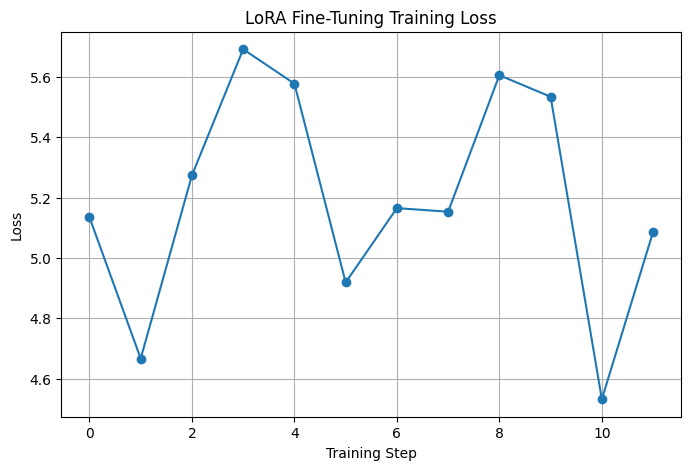

In [20]:
loss_history = []

for log in trainer.state.log_history:

    if "loss" in log:

        loss_history.append(
            log["loss"]
        )


plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    marker="o"
)

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.title(
    "LoRA Fine-Tuning Training Loss"
)

plt.grid()

plt.show()

In [21]:
trainable = 0
frozen = 0

for name, parameter in model.named_parameters():

    if parameter.requires_grad:

        trainable += parameter.numel()

    else:

        frozen += parameter.numel()


print("Trainable parameters:", trainable)

print("Frozen parameters:", frozen)

print(
    "Trainable percentage:",
    round(
        100 * trainable /
        (trainable + frozen),
        4
    ),
    "%"
)

Trainable parameters: 73728
Frozen parameters: 81912576
Trainable percentage: 0.0899 %


In [22]:
print("\nLoRA parameters:")

for name, parameter in model.named_parameters():

    if "lora_A" in name or "lora_B" in name:

        print(
            name,
            "→",
            tuple(parameter.shape)
        )


LoRA parameters:
base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight → (4, 768)
base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight → (2304, 4)
base_model.model.transformer.h.1.attn.c_attn.lora_A.default.weight → (4, 768)
base_model.model.transformer.h.1.attn.c_attn.lora_B.default.weight → (2304, 4)
base_model.model.transformer.h.2.attn.c_attn.lora_A.default.weight → (4, 768)
base_model.model.transformer.h.2.attn.c_attn.lora_B.default.weight → (2304, 4)
base_model.model.transformer.h.3.attn.c_attn.lora_A.default.weight → (4, 768)
base_model.model.transformer.h.3.attn.c_attn.lora_B.default.weight → (2304, 4)
base_model.model.transformer.h.4.attn.c_attn.lora_A.default.weight → (4, 768)
base_model.model.transformer.h.4.attn.c_attn.lora_B.default.weight → (2304, 4)
base_model.model.transformer.h.5.attn.c_attn.lora_A.default.weight → (4, 768)
base_model.model.transformer.h.5.attn.c_attn.lora_B.default.weight → (2304, 4)


In [23]:
prompt = "Industrial robots"

inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

inputs = {
    key: value.to(model.device)
    for key, value in inputs.items()
}

with torch.no_grad():

    output = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=True,
        temperature=0.7
    )


result = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("Generated text:")
print(result)

Generated text:
Industrial robots in general.







































In [24]:
model.save_pretrained(
    "./robot_lora_adapter"
)

tokenizer.save_pretrained(
    "./robot_lora_adapter"
)

print(
    "LoRA adapter saved successfully!"
)

LoRA adapter saved successfully!


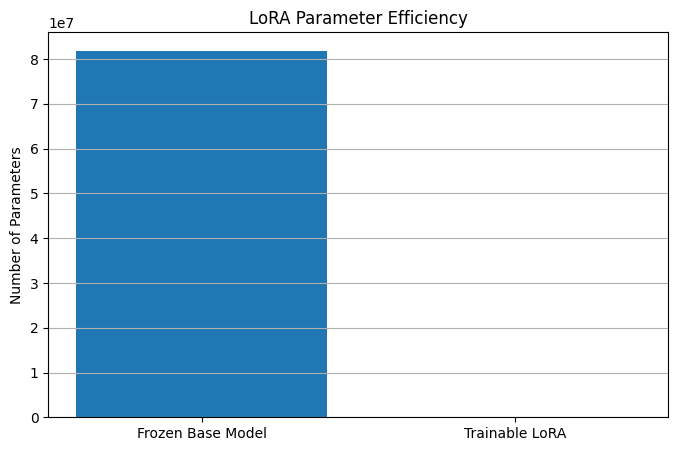

In [25]:
labels = [
    "Frozen Base Model",
    "Trainable LoRA"
]

values = [
    frozen,
    trainable
]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    values
)

plt.ylabel(
    "Number of Parameters"
)

plt.title(
    "LoRA Parameter Efficiency"
)

plt.grid(
    axis="y"
)

plt.show()